In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import StandardScaler

In [ ]:
# --- 工具函數定義 ---
# 固定亂數種子以確保每次執行結果一致 
np.random.seed(seed=67) 

# sigmoid 函式
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# sigmoid 導數函式
def sigmoid_derivative(z):
    # 公式: f'(n) = σ(n)(1 - σ(n))
    s = sigmoid(z)
    return s * (1 - s)

def xavier_init(n_in, n_out):
    limit = np.sqrt(6 / (n_in + n_out))
    return np.random.uniform(-limit, limit, (n_in, n_out))

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def he_init(n_in, n_out):
    limit = np.sqrt(6 / n_in)
    return np.random.uniform(-limit, limit, (n_in, n_out))

def random_init(n_in, n_out, scale=0.01):
    return np.random.uniform(-scale, scale, (n_in, n_out))

# softmax 函式
def softmax(z):
    # 找出 z 中每一列的最大值 c 並維持原本的維度
    c = np.max(z, axis=1, keepdims=True) 
    
    # 數值穩定化
    exp_z = np.exp(z - c)
    
    # 找出每一列的總和並維持原本的維度
    total_exp_z = np.sum(exp_z, axis=1, keepdims=True) 
    
    # 計算並維持原本的維度
    a = exp_z / total_exp_z
    return a

# 交叉熵損失函式
def cross_entropy_loss(a, y):
    loss = -np.sum(y * np.log(a)) / a.shape[0]
    return loss

# 計算準確率函式
def calculate_accuracy(a, y):
    # 列出每一列模型輸出機率的最大值位置 --> 預測標籤
    predicted_labels = np.argmax(a, axis=1)
    
    # 列出原數據每一列的最大值的位置 --> 真實標籤 
    true_labels = np.argmax(y, axis=1)
    
    # 逐一比較預測標籤和真實標籤是否相等
    # 然後計算布林陣列中 "True" 的平均值，即為準確率
    accuracy = np.mean(predicted_labels == true_labels)
    return accuracy

def forward_pass(X, w1, b1, w2, b2):
    z1 = X @ w1 + b1
    
    h1 = relu(z1)
        
    z2 = h1 @ w2 + b2
    return softmax(z2)

def encode_labels(df):
    labels = np.zeros((df.shape[0], 4))
    for i in range(df.shape[0]):
        val = df.iloc[i]['DIQ010']
        if val == 1.0: 
            labels[i] = [0, 0, 0, 1]  # 有糖尿病
        elif val == 2.0: 
            labels[i] = [0, 0, 1, 0]  # 無糖尿病
        elif val == 3.0: 
            labels[i] = [0, 1, 0, 0]  # 邊緣性
        elif val == 9.0: 
            labels[i] = [1, 0, 0, 0]  # 無法回答
    return labels

Epoch 20/200 - Loss: 0.2710 - Val Acc: 0.8985
Epoch 40/200 - Loss: 0.2555 - Val Acc: 0.9000
Epoch 60/200 - Loss: 0.2466 - Val Acc: 0.9000
Epoch 80/200 - Loss: 0.2402 - Val Acc: 0.9015
Epoch 100/200 - Loss: 0.2347 - Val Acc: 0.8985
Epoch 120/200 - Loss: 0.2310 - Val Acc: 0.9000
Epoch 140/200 - Loss: 0.2271 - Val Acc: 0.8985
Epoch 160/200 - Loss: 0.2251 - Val Acc: 0.9000
Epoch 180/200 - Loss: 0.2191 - Val Acc: 0.9030
Epoch 200/200 - Loss: 0.2156 - Val Acc: 0.9045

Final Test Accuracy (17-18 Data): 89.95%


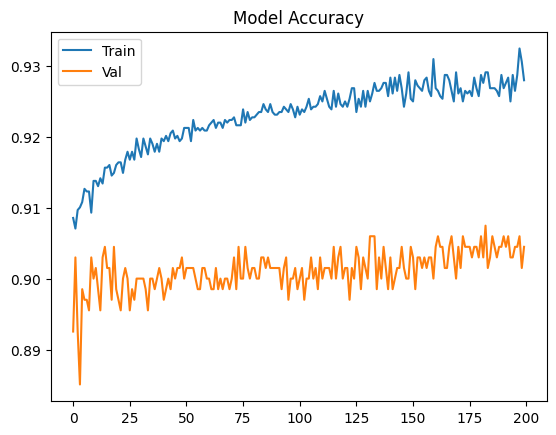

In [ ]:
# --- 數據載入與預處理 ---
# 載入 21-23 訓練集與 17-18 測試集
train_data = pd.read_csv('./data_set/original_nhanes_cleaned_21_23.csv')
test_data = pd.read_csv('./data_set/nhanes_cleaned_17_18.csv')

# one-hot 編碼標籤
Y_train = encode_labels(train_data)
Y_test = encode_labels(test_data)

# 移除不具特徵意義的序列號
train_data = train_data.drop(columns=['SEQN'])
test_data = test_data.drop(columns=['SEQN'])

# 移除 Label
X_train_raw = train_data.drop(columns=['DIQ010'])
X_test_raw = test_data.drop(columns=['DIQ010'])

# 執行標準化： fit 僅用於訓練集
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# 從訓練集中切分出驗證集
split = int(X_train.shape[0] * 0.8)
X_val = X_train[split:]
Y_val = Y_train[split:]
X_train = X_train[:split]
Y_train = Y_train[:split]

# --- 參數初始化 ---
input_Neurons = X_train.shape[1]
hidden_Neurons = 512 
output_Neurons = 4

w1 = he_init(input_Neurons, hidden_Neurons)
w2 = he_init(hidden_Neurons, output_Neurons)
b1 = np.zeros((1, hidden_Neurons))
b2 = np.zeros((1, output_Neurons))

lr = 0.005
epochs = 200
batch_size = 32
n_batches = int(X_train.shape[0] / batch_size)

train_loss_history, val_loss_history = [], []
train_acc_history, val_acc_history = [], []
best_val_accuracy = 0.0
best_params = {}

# --- 訓練流程 ---
for epoch in range(epochs):
    perm = np.random.permutation(X_train.shape[0])
    X_shuffled, Y_shuffled = X_train[perm], Y_train[perm]
    
    for i in range(n_batches):
        start = i * batch_size
        end = start + batch_size
        X_batch, Y_batch = X_shuffled[start:end], Y_shuffled[start:end]
        curr_bs = X_batch.shape[0]

        # 順向傳播
        n1 = X_batch @ w1 + b1
        a1 = relu(n1)
        n2 = a1 @ w2 + b2
        a2 = softmax(n2)
        
        # 反向傳播
        grad2 = a2 - Y_batch
        grad_w2 = a1.T @ grad2 / curr_bs
        grad_b2 = np.sum(grad2, axis=0, keepdims=True) / curr_bs
        
        d_act = relu_derivative(n1)
        grad1 = (grad2 @ w2.T) * d_act
        grad_w1 = X_batch.T @ grad1 / curr_bs
        grad_b1 = np.sum(grad1, axis=0, keepdims=True) / curr_bs
        
        # 更新權重
        w1 -= lr * grad_w1
        b1 -= lr * grad_b1
        w2 -= lr * grad_w2
        b2 -= lr * grad_b2
    
    # 評估
    a_train = forward_pass(X_train, w1, b1, w2, b2)
    a_val = forward_pass(X_val, w1, b1, w2, b2)
    
    t_loss, v_loss = cross_entropy_loss(a_train, Y_train), cross_entropy_loss(a_val, Y_val)
    t_acc, v_acc = calculate_accuracy(a_train, Y_train), calculate_accuracy(a_val, Y_val)
    
    train_loss_history.append(t_loss)
    val_loss_history.append(v_loss)
    train_acc_history.append(t_acc)
    val_acc_history.append(v_acc)
    
    if v_acc > best_val_accuracy:
        best_val_accuracy = v_acc
        best_params = {"w1": w1.copy(), "b1": b1.copy(), "w2": w2.copy(), "b2": b2.copy()}

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {t_loss:.4f} - Val Acc: {v_acc:.4f}")

# --- 測試集最終評估 ---
a_test = forward_pass(X_test, best_params["w1"], best_params["b1"], best_params["w2"], best_params["b2"])
test_acc = calculate_accuracy(a_test, Y_test)
print(f"\nFinal Test Accuracy (17-18 Data): {test_acc*100:.2f}%")

# 映射回原始標籤
original_labels = np.array([9.0, 3.0, 2.0, 1.0])
predicted_indices = np.argmax(a_test, axis=1)
predicted_original = original_labels[predicted_indices]

# 儲存視覺化結果
if not os.path.exists("./output"): os.makedirs("./output")
plt.plot(train_acc_history, label="Train")
plt.plot(val_acc_history, label="Val")
plt.title("Model Accuracy")
plt.legend()
plt.savefig("./output/accuracy_curve.png")  

In [31]:
import joblib

# 保存神經網路參數
np.savez('./output/best_model_params.npz', 
         w1=best_params["w1"], b1=best_params["b1"], 
         w2=best_params["w2"], b2=best_params["b2"])

# 保存標準化工具 (Scaler)
joblib.dump(scaler, './output/scaler.joblib')

['./output/scaler.joblib']